In [21]:
import sys
sys.path.append('WTM')

import pickle as p
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
import seaborn as sns
import new_ds
from new_ds import mm_Dataset
from WTM_model import WTM
from utils import calc_topic_uniqueness
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
pd.set_option('display.max_rows', None)
import pickle

import seaborn as sns
import networkx as nx
import time

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['svg.fonttype'] = 'none'

In [ ]:
#Ref 1.2 The authors observed that the distribution of topics is quite different for different case-studies. It would be interesting to investigate what is the distribution of features (on average) in the data, is it different? For instance in text based topic modeling one expects that word distribution is power-law. 

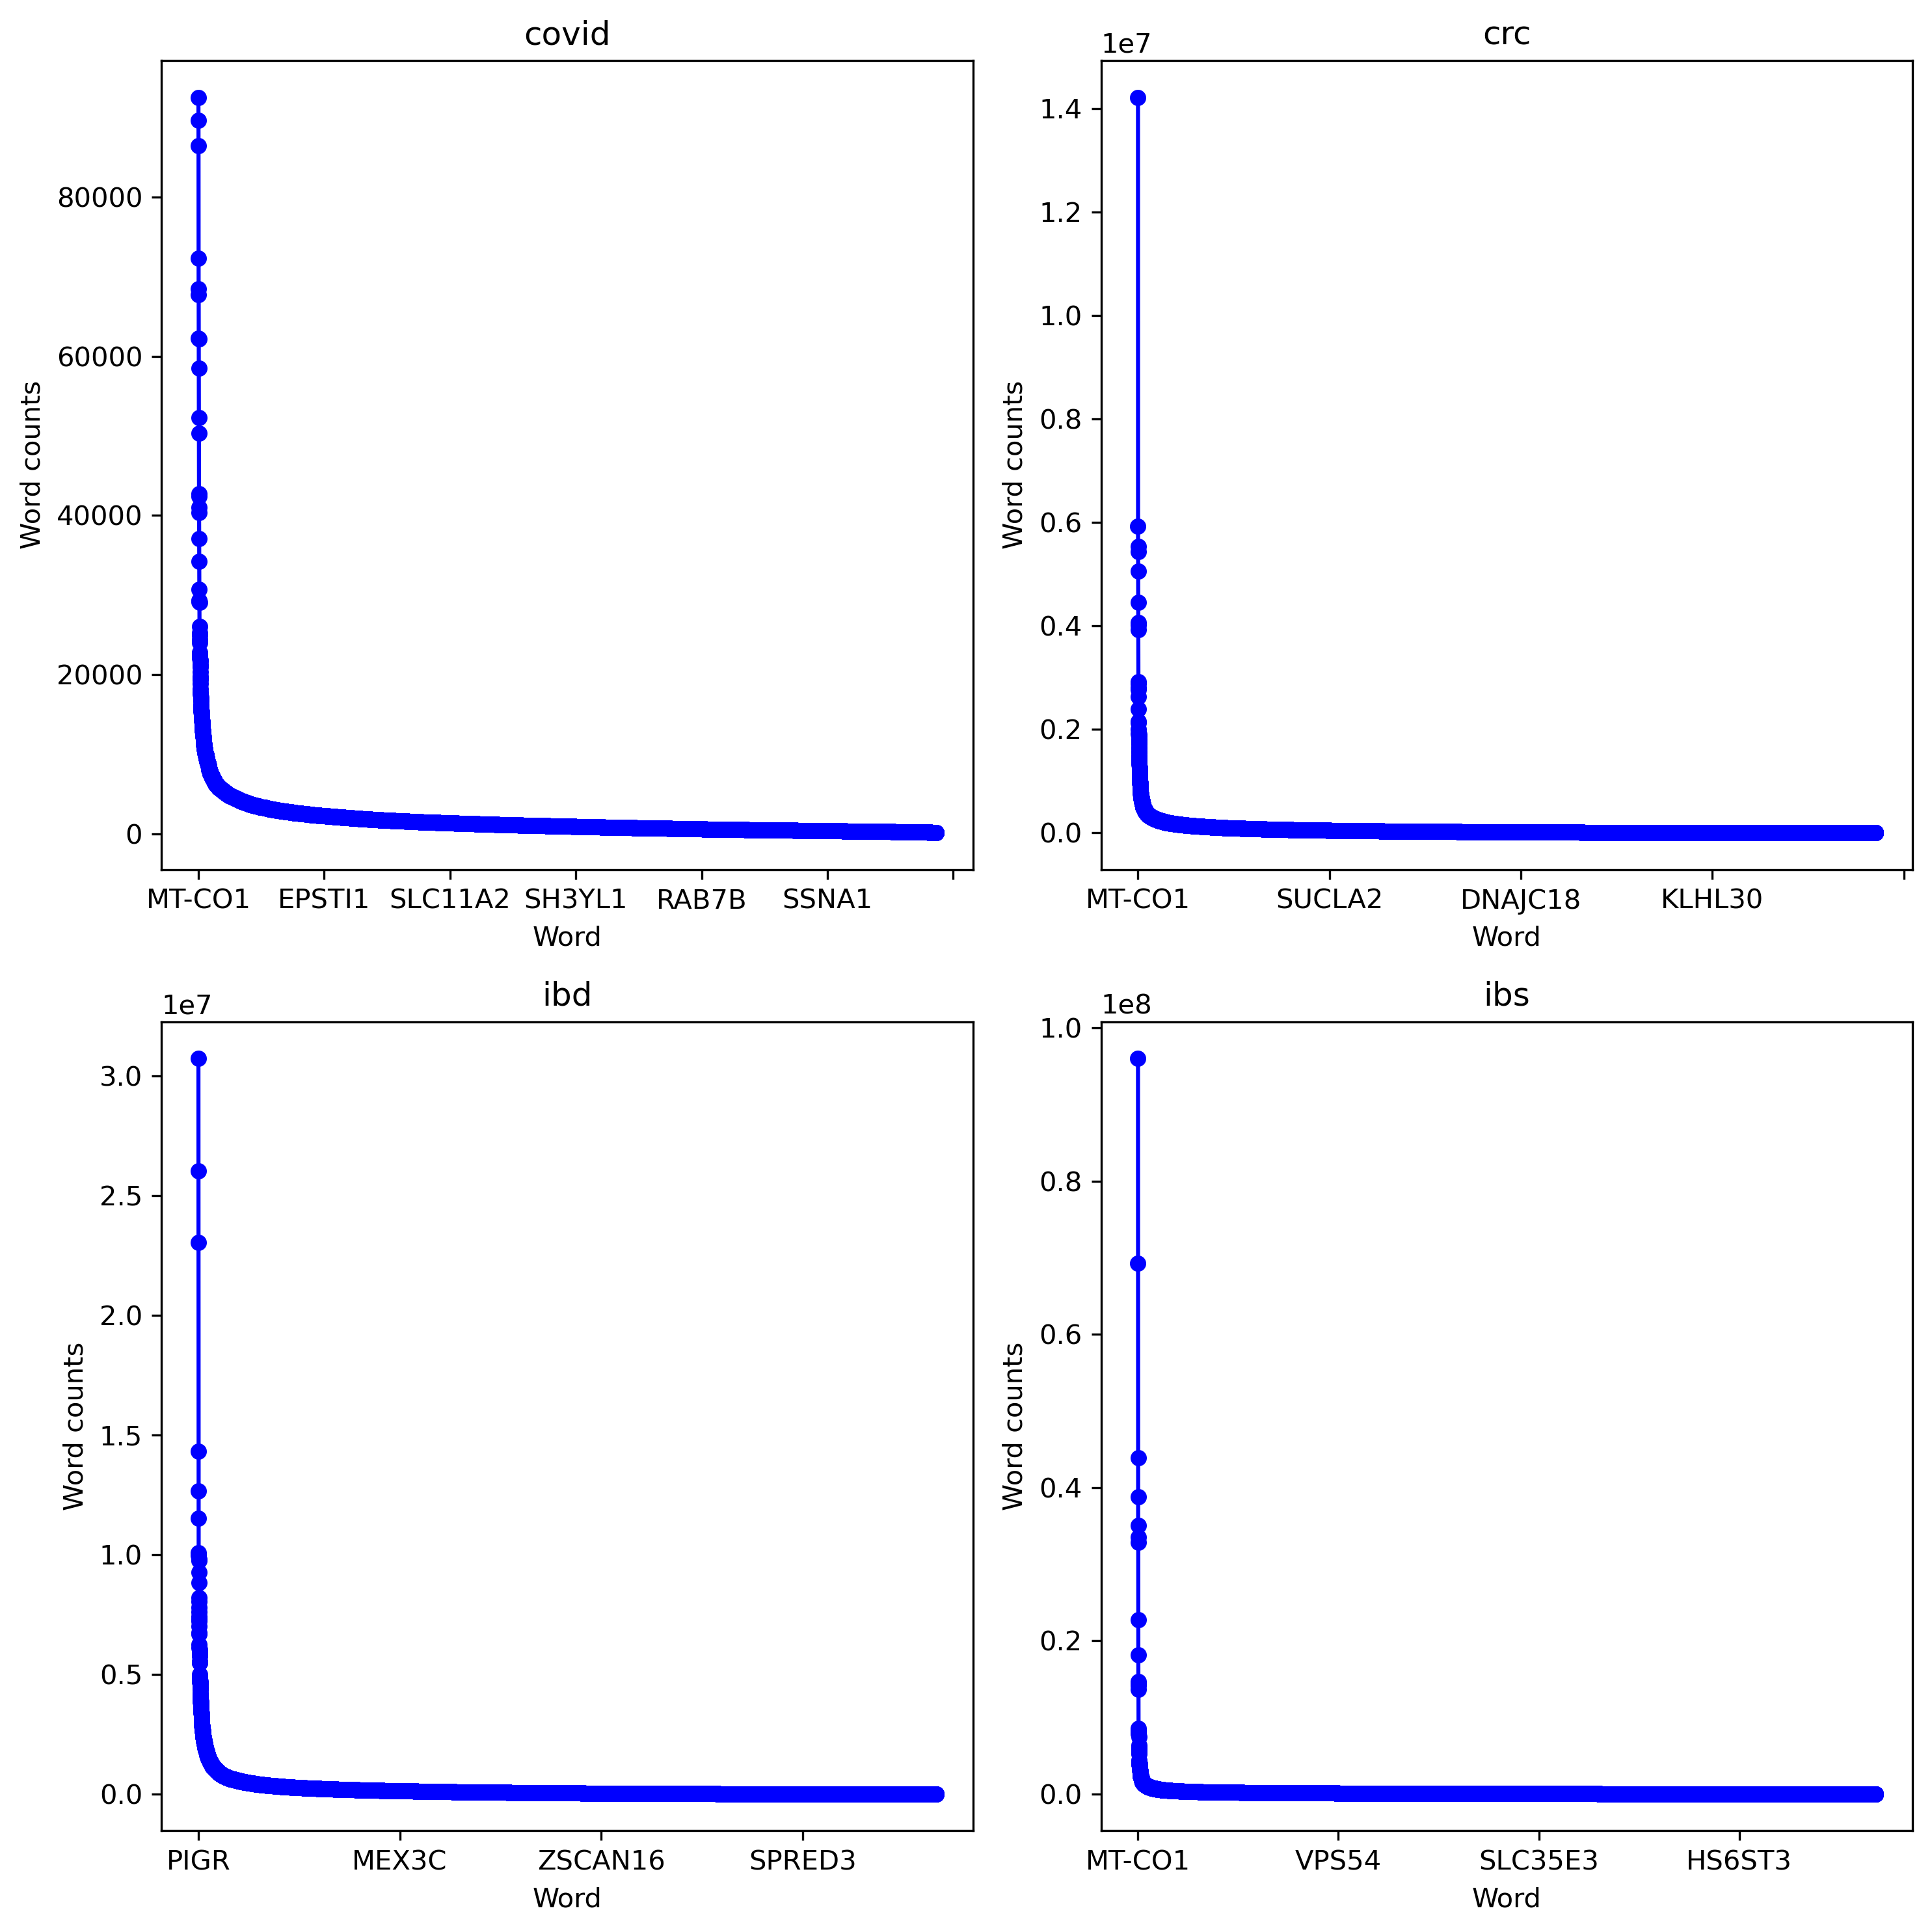

In [5]:
# get the word distribution, gene counts distribution
data_name = "covid"
data_list = ['covid','crc','ibd','ibs']

fig, axes = plt.subplots(2, 2, figsize=(10, 10), dpi=300)
axes_f = axes.flatten()
for i in range(4):
    data_name = data_list[i]
    data_path = f"{data_name}_data/{data_name}_gene.csv"
    df_data = pd.read_csv(data_path,header=0,index_col=0)
    df_data_word_cnt_all_sample =  df_data.sum(axis=0).to_frame()
    df_data_word_cnt_all_sample_sorted = df_data_word_cnt_all_sample.sort_values(by=0, ascending=False)
    # Plot using DataFrame.plot() and pass ax
    df_data_word_cnt_all_sample_sorted.plot(kind='line', marker='o', markersize=5, ax=axes_f[i], title=f"{data_name}", color='b', legend=False)
    # Customize the plot
    axes_f[i].set_ylabel("Word counts")
    axes_f[i].set_xlabel("Word")
#ax.set_xticklabels(df_data_word_cnt_all_sample_sorted.index, rotation=45)

plt.tight_layout()
plt.savefig("word_counts_distribution_power_law.svg")
plt.savefig("word_counts_distribution_power_law.png")

In [ ]:
# 1.5 How does the number of parameters of WAE scales with the number of topics? This is not clear to me. Moreover, how does the complexity of WAE scale with the number of topics?

n_topic =   5: Parameters = 1,187,845
n_topic =  10: Parameters = 1,191,690
n_topic =  20: Parameters = 1,199,380
n_topic =  50: Parameters = 1,222,450
n_topic = 100: Parameters = 1,260,900
n_topic = 200: Parameters = 1,337,800
n_topic = 400: Parameters = 1,491,600


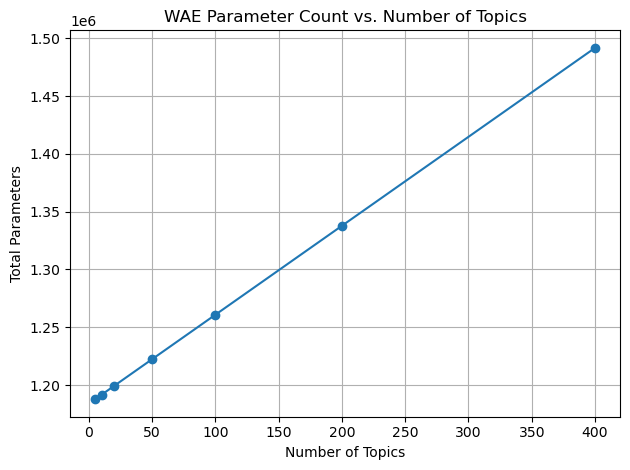

In [64]:
import torch
from wae import WAE
import matplotlib.pyplot as plt

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# You can vary the number of topics here
topic_list = [5, 10, 20, 50, 100, 200, 400]
param_counts = []

for n_topic in topic_list:
    model = WAE(
        encode_dims=[1024, 512, 256, n_topic],  # latent dim = n_topic
        decode_dims=[n_topic, 512, 1024],       # decoder input = n_topic
        dropout=0.1
    )
    n_params = count_params(model)
    param_counts.append(n_params)
    print(f"n_topic = {n_topic:>3}: Parameters = {n_params:,}")

# Plotting
plt.plot(topic_list, param_counts, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("Total Parameters")
plt.title("WAE Parameter Count vs. Number of Topics")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#Ref 1.6  When the model is run with a large number of topics what is the distribution of values in the topics (see Fig 2). I wonder if all the topics are really used or if some weights are simpli put to zero and so part of the model is not really used.

In [6]:
# get names of model checkpoints

ckpts_covid_t10_a5e2 = [f'covid_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]# best one!
ckpts_crc_t10_a5e2 = [f'crc_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibd_t10_a5e2 = [f'ibd_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]
ckpts_ibs_t10_a5e2 = [f'ibs_tp10_a0.05_lr0.0005/{i*10}.ckpt' for i in range(1, 51)]

#load expression data
covid_docSet = mm_Dataset(rebuild=True,
                        data_dir='/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/covid_data',
                        mode_names=['gene', 'microbeR', 'premiR'],
                        expmat_fnames=['covid_gene.csv', 'covid_microbeR.csv', 'covid_premiR.csv'],
                        metadata_fname='covid_metadata.csv',
                        out_fname='covid_docDataset.pkl',
                        scale='gene'
                       )

crc_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/crc_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['crc_gene.csv', 'crc_microbeR.csv'],
                        metadata_fname = 'crc_metadata.csv',
                        out_fname = 'crc_docDataset.pkl'
                       )

ibd_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/ibd_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibd_gene.csv', 'ibd_microbeR.csv'],
                        metadata_fname = 'ibd_metadata.csv',
                        out_fname = 'ibd_docDataset.pkl')

ibs_docSet = mm_Dataset(rebuild=True,
                        data_dir = '/gpfs/gibbs/pi/gerstein/pn269/ntm4pengyu_revision/privacy_network/ibs_data',
                        mode_names = ['gene', 'microbeR'],
                        expmat_fnames = ['ibs_gene.csv', 'ibs_microbeR.csv'],
                        metadata_fname = 'ibs_metadata.csv',
                        out_fname = 'ibs_docDataset.pkl')

Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding
Rebuilding
successfully saved after rebuilding


In [7]:
def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

In [9]:
###get embedding, word distributions (06/02/2025/)
data_list = ['covid','crc','ibd','ibs']
data_name = data_list[0]
models_name_list = globals()[f"ckpts_{data_name}_t10_a5e2"]
dataset = globals()[f"{data_name}_docSet"]
model_name = models_name_list[-1]
curr_model = load_model(model_name, dataset)
embeds_df = get_embeds(curr_model, dataset)

In [9]:
def my_softmax(df):
    
    maxes = df.max(axis=1)
    diffs = df.sub(maxes, axis=0)
    num = np.exp(diffs)
    denom = num.sum(axis=1)
    out = num.div(denom, axis=0)
    return out

def load_model(model_prefix, docSet):
    checkpoint = torch.load(f'WTM_checkpoints/{model_prefix}')
    param = checkpoint["param"]
    model = WTM(**param)
    model.load_model(checkpoint["net"])
    model.id2token = {v: k for k,v in docSet.dictionary.token2id.items()}
    return model

def get_embeds(model, docSet, labels_fname = None):
    embeds = model.get_embed(train_data=docSet, num=1000)

    if labels_fname:
        with open(labels_fname, 'r') as file:
            labels_list = [line.strip() for line in file.readlines()]
        out_df = pd.DataFrame(embeds, index=labels_list)
        return out_df
        
    return pd.DataFrame(embeds)

def calculate_phis(docSet, model):
    out_dict = {}
    all_phi_raw = model.get_topic_word_dist(normalize=False)
    headers = np.concatenate([expmat.columns for expmat in docSet.expmats.values()])
    all_phi_raw = pd.DataFrame(all_phi_raw, columns = headers)
    for data_type in np.unique(docSet.label_type):
        type_raw = all_phi_raw.iloc[:, docSet.label_type==data_type]
        out_dict[data_type] = my_softmax(type_raw)
    return out_dict

In [11]:
#get gene index which kept in wtm model
df_gene = pd.read_csv("covid_data/covid_gene.csv",header=0,index_col=None, sep=",")
stopwords = []
df_gene_clean = df_gene.loc[:, (~df_gene.columns.str.startswith('MT-')) & (~df_gene.columns.isin(stopwords)) & (df_gene.sum(axis=0)!=0)]
selected_genes = (~df_gene.columns.str.startswith('MT-')) & (~df_gene.columns.isin(stopwords)) & (df_gene.sum(axis=0)!=0)
selected_genes_index = selected_genes[1:].to_frame()[0].to_list()

#get the gene dist in 10 topics in wtm model
curr_model = load_model(ckpts_covid_t10_a5e2[-1], covid_docSet)
curr_phis = calculate_phis(covid_docSet, curr_model)
df_gene_topic_phi = curr_phis['gene']
df_gene_topic_phi.columns = df_gene_clean.columns[1:].to_list()
#df_gene_topic_phi.to_csv("covid_wtm_phi_gene_dist.csv")


#get the gene dist across 10 topics in mlda model
df_hostgene = pd.read_csv("dat_for_mlda/data_15000/hostgene_m1.txt", header=None,index_col=None,sep="\t")
df_hostgene_mlda_phi = pd.read_csv("mlda_training_outputs/T10_N25_V15000/T10_N25_V15000-m1-hostgene.phi.txt", sep=",", header=None, index_col=None)
df_hostgene_match_wtm_mlda_phi = df_hostgene_mlda_phi.loc[selected_genes_index,:].T
df_hostgene_match_wtm_mlda_phi.columns = df_gene_clean.columns[1:].to_list()
#df_hostgene_match_wtm_mlda_phi.to_csv("covid_mlda_phi_gene_dist.csv")

In [ ]:
# compare topic gene distriubtion in mlda and wtm

In [111]:
df_hostgene_match_wtm_mlda_phi

,FO538757.2,NOC2L,KLHL17,PERM1,ISG15,AGRN,C1ORF159,TTLL10,SDF4,B3GALT6,...,TSPY4,TSPY8,TSPY3,TSPY10,USP9Y,DDX3Y,UTY,NLGN4Y,KDM5D,EIF1AY
0,0.000064,0.000066,0.000009,0.000032,0.000069,0.000094,0.000030,0.000010,0.000087,0.000017,...,0.000052,0.000057,0.000071,0.000043,0.000030,0.000047,0.000052,0.000006,0.000032,0.000017
1,0.000067,0.000061,0.000017,0.000039,0.000115,0.000121,0.000038,0.000029,0.000130,0.000027,...,0.000042,0.000054,0.000068,0.000064,0.000021,0.000048,0.000033,0.000007,0.000028,0.000009
2,0.000060,0.000064,0.000019,0.000049,0.000089,0.000087,0.000022,0.000014,0.000142,0.000023,...,0.000049,0.000056,0.000064,0.000049,0.000023,0.000037,0.000032,0.000003,0.000027,0.000011
3,0.000051,0.000062,0.000015,0.000033,0.000088,0.000082,0.000038,0.000012,0.000106,0.000024,...,0.000062,0.000045,0.000061,0.000054,0.000028,0.000053,0.000038,0.000009,0.000027,0.000017
4,0.000067,0.000065,0.000012,0.000041,0.000088,0.000091,0.000039,0.000021,0.000147,0.000032,...,0.000059,0.000042,0.000064,0.000047,0.000021,0.000041,0.000033,0.000007,0.000026,0.000013
5,0.000048,0.000070,0.000010,0.000028,0.000086,0.000112,0.000023,0.000017,0.000103,0.000020,...,0.000046,0.000065,0.000062,0.000062,0.000032,0.000053,0.000038,0.000007,0.000034,0.000011
6,0.000044,0.000038,0.000005,0.000017,0.000049,0.000084,0.000016,0.000004,0.000078,0.000014,...,0.000051,0.000051,0.000061,0.000066,0.000048,0.000084,0.000068,0.000011,0.000060,0.000020
7,0.000036,0.000028,0.000005,0.000017,0.000048,0.000047,0.000014,0.000008,0.000077,0.000007,...,0.000066,0.000074,0.000102,0.000077,0.000066,0.000113,0.000086,0.000019,0.000080,0.000030
8,0.000050,0.000066,0.000005,0.000025,0.000076,0.000093,0.000034,0.000014,0.000110,0.000021,...,0.000053,0.000069,0.000062,0.000052,0.000029,0.000043,0.000036,0.000011,0.000032,0.000013
9,0.000074,0.000056,0.000013,0.000035,0.000083,0.000115,0.000030,0.000024,0.000121,0.000020,...,0.000043,0.000047,0.000052,0.000055,0.000029,0.000049,0.000035,0.000006,0.000028,0.000011


In [112]:
df_gene_topic_phi

,FO538757.2,NOC2L,KLHL17,PERM1,ISG15,AGRN,C1ORF159,TTLL10,SDF4,B3GALT6,...,TSPY4,TSPY8,TSPY3,TSPY10,USP9Y,DDX3Y,UTY,NLGN4Y,KDM5D,EIF1AY
0,0.000053,0.000054,0.000013,0.000051,0.000022,0.000086,0.000045,0.000020,0.000085,0.000022,...,0.000129,0.000145,0.000167,0.000140,0.000070,0.000066,0.000098,0.000013,0.000065,0.000015
1,0.000054,0.000031,0.000008,0.000007,0.000115,0.000036,0.000007,0.000003,0.000063,0.000011,...,0.000010,0.000012,0.000014,0.000011,0.000071,0.000133,0.000094,0.000008,0.000077,0.000022
2,0.000039,0.000053,0.000015,0.000097,0.000026,0.000175,0.000105,0.000036,0.000109,0.000046,...,0.000237,0.000249,0.000322,0.000267,0.000011,0.000021,0.000027,0.000015,0.000024,0.000012
3,0.000045,0.000064,0.000010,0.000052,0.000035,0.000092,0.000032,0.000015,0.000135,0.000019,...,0.000059,0.000062,0.000080,0.000065,0.000031,0.000068,0.000035,0.000014,0.000042,0.000022
4,0.000036,0.000034,0.000004,0.000005,0.000199,0.000029,0.000003,0.000005,0.000085,0.000006,...,0.000018,0.000019,0.000022,0.000017,0.000039,0.000069,0.000062,0.000012,0.000036,0.000019
5,0.000060,0.000058,0.000005,0.000005,0.000048,0.000089,0.000006,0.000005,0.000114,0.000010,...,0.000004,0.000004,0.000005,0.000005,0.000049,0.000099,0.000059,0.000009,0.000065,0.000022
6,0.000055,0.000055,0.000005,0.000003,0.000052,0.000089,0.000005,0.000004,0.000110,0.000009,...,0.000002,0.000003,0.000003,0.000003,0.000049,0.000085,0.000057,0.000008,0.000061,0.000019
7,0.000044,0.000062,0.000010,0.000028,0.000052,0.000098,0.000024,0.000017,0.000159,0.000020,...,0.000066,0.000073,0.000105,0.000075,0.000020,0.000059,0.000036,0.000010,0.000044,0.000019
8,0.000066,0.000039,0.000003,0.000012,0.000066,0.000067,0.000005,0.000004,0.000089,0.000011,...,0.000003,0.000003,0.000003,0.000003,0.000047,0.000086,0.000046,0.000014,0.000037,0.000019
9,0.000055,0.000056,0.000014,0.000039,0.000022,0.000075,0.000029,0.000024,0.000071,0.000016,...,0.000113,0.000131,0.000154,0.000122,0.000049,0.000024,0.000086,0.000014,0.000033,0.000009


In [12]:
# Normalize topics to sum to 1 (i.e., probability distributions)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment
from scipy.special import rel_entr  # for KL divergence

df_hostgene_match_wtm_mlda_phi_normalized = df_hostgene_match_wtm_mlda_phi.div(df_hostgene_match_wtm_mlda_phi.sum(axis=1), axis=0)
df_gene_topic_phi_normalized = df_gene_topic_phi.div(df_gene_topic_phi.sum(axis=1), axis=0)

In [13]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.special import rel_entr
import matplotlib.pyplot as plt
import networkx as nx

In [14]:
# --- Jensen-Shannon Distance function ---
def jensen_shannon(p, q):
    p = np.array(p)
    q = np.array(q)
    m = 0.5 * (p + q)
    jsd = 0.5 * np.sum(rel_entr(p, m)) + 0.5 * np.sum(rel_entr(q, m))
    return np.sqrt(jsd)  # return actual JSD (square root of JS divergence)

# --- Input dataframes (already normalized topic matrices) ---

df_hostgene_match_wtm_mlda_phi_normalized = df_hostgene_match_wtm_mlda_phi.div(df_hostgene_match_wtm_mlda_phi.sum(axis=1), axis=0)
df_gene_topic_phi_normalized = df_gene_topic_phi.div(df_gene_topic_phi.sum(axis=1), axis=0)
# --- Add small epsilon to avoid log(0) in JSD ---
epsilon = 1e-12
mlda = df_hostgene_match_wtm_mlda_phi_normalized + epsilon
wae = df_gene_topic_phi_normalized + epsilon

In [15]:
mlda

,FO538757.2,NOC2L,KLHL17,PERM1,ISG15,AGRN,C1ORF159,TTLL10,SDF4,B3GALT6,...,TSPY4,TSPY8,TSPY3,TSPY10,USP9Y,DDX3Y,UTY,NLGN4Y,KDM5D,EIF1AY
0,0.000066,0.000068,0.000009,0.000033,0.000071,0.000096,0.000031,0.000010,0.000089,0.000018,...,0.000053,0.000058,0.000073,0.000044,0.000030,0.000048,0.000054,0.000006,0.000033,0.000017
1,0.000069,0.000062,0.000018,0.000040,0.000118,0.000124,0.000039,0.000030,0.000132,0.000028,...,0.000042,0.000055,0.000070,0.000065,0.000021,0.000049,0.000034,0.000007,0.000028,0.000010
2,0.000061,0.000065,0.000019,0.000050,0.000091,0.000089,0.000022,0.000014,0.000145,0.000023,...,0.000050,0.000057,0.000065,0.000050,0.000024,0.000038,0.000033,0.000003,0.000027,0.000011
3,0.000052,0.000064,0.000015,0.000034,0.000090,0.000084,0.000039,0.000013,0.000109,0.000025,...,0.000063,0.000046,0.000062,0.000055,0.000029,0.000055,0.000039,0.000009,0.000027,0.000017
4,0.000068,0.000066,0.000012,0.000042,0.000090,0.000093,0.000040,0.000021,0.000150,0.000033,...,0.000060,0.000043,0.000066,0.000048,0.000022,0.000042,0.000034,0.000007,0.000026,0.000014
5,0.000049,0.000072,0.000010,0.000028,0.000088,0.000115,0.000023,0.000018,0.000106,0.000021,...,0.000047,0.000066,0.000063,0.000064,0.000033,0.000054,0.000039,0.000007,0.000035,0.000011
6,0.000046,0.000039,0.000005,0.000018,0.000051,0.000088,0.000017,0.000005,0.000081,0.000015,...,0.000053,0.000052,0.000064,0.000068,0.000050,0.000087,0.000070,0.000012,0.000062,0.000021
7,0.000038,0.000030,0.000005,0.000018,0.000050,0.000050,0.000015,0.000008,0.000082,0.000007,...,0.000070,0.000078,0.000108,0.000081,0.000069,0.000119,0.000090,0.000020,0.000084,0.000032
8,0.000051,0.000068,0.000005,0.000025,0.000078,0.000095,0.000035,0.000014,0.000113,0.000021,...,0.000055,0.000071,0.000063,0.000053,0.000030,0.000044,0.000037,0.000011,0.000033,0.000013
9,0.000076,0.000057,0.000014,0.000036,0.000085,0.000117,0.000031,0.000025,0.000124,0.000020,...,0.000044,0.000048,0.000053,0.000056,0.000030,0.000050,0.000036,0.000006,0.000029,0.000011


Matched Topics (WAE → mLDA) using Jensen-Shannon Distance:
   WAE_Topic  mLDA_Topic  Jensen_Shannon_Distance  Similarity
0          0           2                 0.162056    0.837944
1          1           3                 0.201832    0.798168
2          2           4                 0.268490    0.731510
3          3           5                 0.146818    0.853182
4          4           9                 0.212339    0.787661
5          5           6                 0.166961    0.833039
6          6           7                 0.190205    0.809795
7          7           8                 0.125698    0.874302
8          8           0                 0.235494    0.764506
9          9           1                 0.193930    0.806070


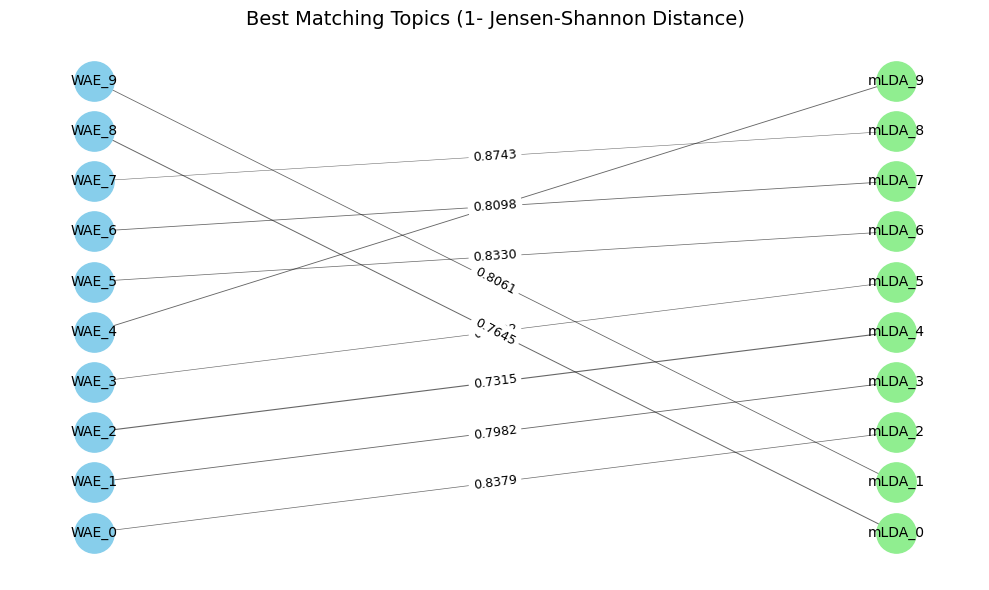

In [142]:
# --- Compute JSD matrix ---
num_mlda = mlda.shape[0]
num_wae = wae.shape[0]
jsd_matrix = np.zeros((num_mlda, num_wae))

for i in range(num_mlda):
    for j in range(num_wae):
        jsd_matrix[i, j] = jensen_shannon(mlda.iloc[i].values, wae.iloc[j].values)

# --- Optimal Matching: Hungarian algorithm (minimize JSD) ---
row_ind, col_ind = linear_sum_assignment(jsd_matrix)

# --- Build matching dataframe with JSD ---
match_df = pd.DataFrame({
    'WAE_Topic': col_ind,
    'mLDA_Topic': row_ind,
    'Jensen_Shannon_Distance': jsd_matrix[row_ind, col_ind],
    'Similarity': 1 - jsd_matrix[row_ind, col_ind]
}).sort_values(by='WAE_Topic').reset_index(drop=True)

print("Matched Topics (WAE → mLDA) using Jensen-Shannon Distance:")
print(match_df)

# --- Plot Bipartite Network ---
G = nx.Graph()

wae_nodes = [f"WAE_{i}" for i in range(num_wae)]
mlda_nodes = [f"mLDA_{i}" for i in range(num_mlda)]
G.add_nodes_from(wae_nodes, bipartite=0)
G.add_nodes_from(mlda_nodes, bipartite=1)

for wae_idx, mlda_idx in zip(col_ind, row_ind):
    wae_node = f"WAE_{wae_idx}"
    mlda_node = f"mLDA_{mlda_idx}"
    jsd = jsd_matrix[mlda_idx, wae_idx]
    similarity = 1 - jsd
    G.add_edge(wae_node, mlda_node, weight=similarity )

# Bipartite layout
pos = dict()
pos.update((node, (0, i)) for i, node in enumerate(wae_nodes))
pos.update((node, (1, i)) for i, node in enumerate(mlda_nodes))

# Draw nodes
plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G, pos, nodelist=wae_nodes, node_color='skyblue', node_size=800, label='WAE')
nx.draw_networkx_nodes(G, pos, nodelist=mlda_nodes, node_color='lightgreen', node_size=800, label='mLDA')

# Draw edges
edges = G.edges(data=True)
edge_labels = {(u, v): f"{d['weight']:.4f}" for u, v, d in edges}
edge_weights = [3 * (1 - d['weight']) for (_, _, d) in edges]  # thicker = more similar

nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_weights, alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Best Matching Topics (1- Jensen-Shannon Distance)", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

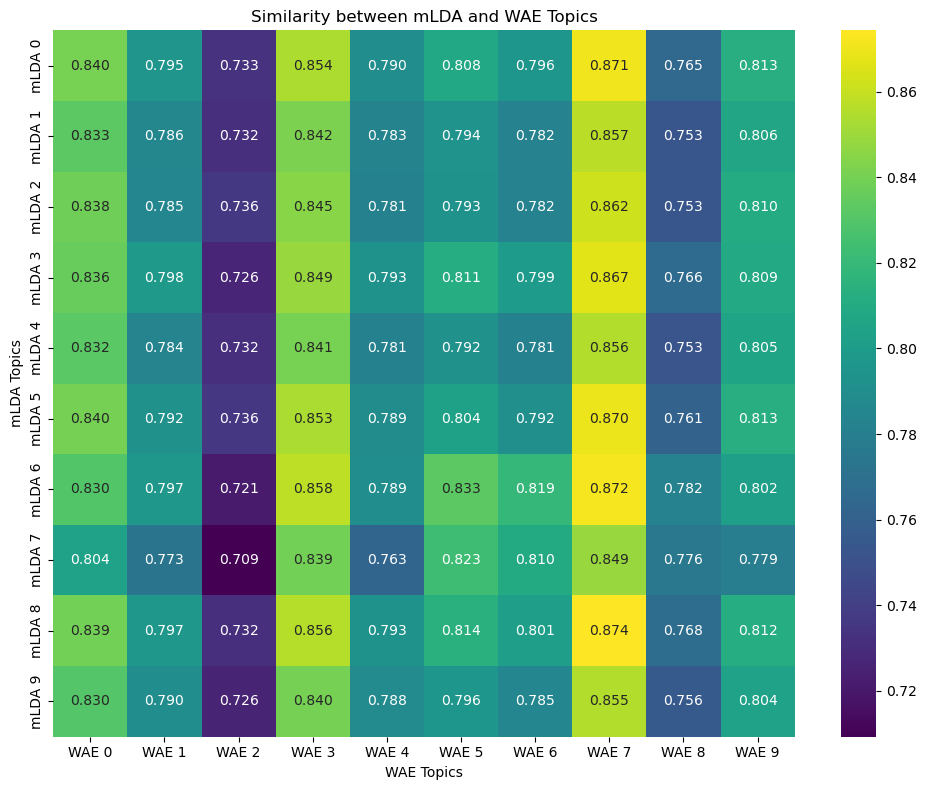

In [145]:
# Plot similarity matrix
plt.figure(figsize=(10, 8))
sns.heatmap(1-jsd_matrix, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=[f"WAE {i}" for i in range(df_hostgene_match_wtm_mlda_phi_normalized.shape[0])],
            yticklabels=[f"mLDA {i}" for i in range(df_gene_topic_phi_normalized.shape[0])])
plt.title("Similarity between mLDA and WAE Topics")
plt.xlabel("WAE Topics")
plt.ylabel("mLDA Topics")
plt.tight_layout()
plt.show()

In [ ]:
#get gene index which kept in wtm model
#Ref 3.2 analysis

In [10]:
###get embedding, word distributions of 4 datasets(06/03/2025/)

data_list = ['covid','crc','ibd','ibs']
for data_name in data_list:
    models_name_list = globals()[f"ckpts_{data_name}_t10_a5e2"]
    dataset = globals()[f"{data_name}_docSet"]

    ####get select gene index 
    df_gene = pd.read_csv(f"{data_name}_data/{data_name}_gene.csv",header=0,index_col=None, sep=",")
    stopwords = []
    df_gene_clean = df_gene.loc[:, (~df_gene.columns.str.startswith('MT-')) & (~df_gene.columns.isin(stopwords)) & (df_gene.sum(axis=0)!=0)]
    selected_genes = (~df_gene.columns.str.startswith('MT-')) & (~df_gene.columns.isin(stopwords)) & (df_gene.sum(axis=0)!=0)
    selected_genes_index = selected_genes[1:].to_frame()[0].to_list()

    model_name = models_name_list[-1]
    curr_model = load_model(model_name, dataset)
    #get the gene dist in 10 topics in wtm model
    curr_model = load_model(model_name, dataset)
    curr_phis = calculate_phis(dataset, curr_model)
    df_gene_topic_phi = curr_phis['gene']
    df_gene_topic_phi.columns = df_gene_clean.columns[1:].to_list()
    df_gene_topic_phi.to_csv(f"{data_name}_phi_gene_dist.csv")

In [11]:
####plot topics weights for features
data_list = ['covid','crc','ibd','ibs']
topic_gene_dist_dict = {}
for data_name in data_list:
    df_gene_topic_phi = pd.read_csv(f"{data_name}_phi_gene_dist.csv",header=0,index_col=0)
    topic_gene_dist_dict[data_name] = df_gene_topic_phi.div(df_gene_topic_phi.sum(axis=1), axis=0)

# Step 1: Get a list of sets of column names from each DataFrame
column_gene_sets = [set(df.columns) for df in topic_gene_dist_dict.values()]
# Step 2: Find the intersection (common columns)
common_gene_columns = sorted(list(set.intersection(*column_gene_sets)))

# Step 2: Keep only common columns in all datasets
for dataname in topic_gene_dist_dict:
    topic_gene_dist_dict[dataname] = topic_gene_dist_dict[dataname][common_gene_columns]

In [13]:
topic_gene_dist_dict['covid']

,A1BG,A2M,A2ML1,A4GALT,AAAS,AACS,AAGAB,AAK1,AAMDC,AAMP,...,ZW10,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1
0,0.000019,0.000115,0.000017,0.000025,0.000034,0.000167,0.000029,0.000311,0.000010,0.000047,...,0.000010,0.000015,0.000013,0.000029,0.000037,0.000103,0.000016,0.000091,0.000109,0.000302
1,0.000007,0.000094,0.000013,0.000012,0.000037,0.000044,0.000039,0.000200,0.000019,0.000037,...,0.000023,0.000019,0.000007,0.000020,0.000034,0.000074,0.000004,0.000098,0.000150,0.000225
2,0.000033,0.000193,0.000021,0.000051,0.000009,0.000156,0.000014,0.000159,0.000024,0.000028,...,0.000006,0.000006,0.000011,0.000031,0.000039,0.000101,0.000039,0.000055,0.000066,0.000296
3,0.000027,0.000628,0.000013,0.000049,0.000020,0.000078,0.000035,0.000178,0.000093,0.000063,...,0.000015,0.000011,0.000008,0.000024,0.000028,0.000053,0.000017,0.000110,0.000128,0.000203
4,0.000021,0.000090,0.000018,0.000009,0.000043,0.000092,0.000051,0.000148,0.000028,0.000033,...,0.000018,0.000021,0.000008,0.000022,0.000033,0.000066,0.000006,0.000120,0.000137,0.000120
5,0.000013,0.002687,0.000004,0.000028,0.000027,0.000028,0.000049,0.000148,0.000011,0.000076,...,0.000025,0.000013,0.000011,0.000017,0.000023,0.000033,0.000002,0.000079,0.000197,0.000167
6,0.000005,0.003104,0.000005,0.000024,0.000028,0.000028,0.000052,0.000150,0.000009,0.000068,...,0.000023,0.000013,0.000012,0.000014,0.000021,0.000032,0.000002,0.000079,0.000203,0.000170
7,0.000069,0.000780,0.000016,0.000021,0.000014,0.000100,0.000024,0.000197,0.000058,0.000048,...,0.000017,0.000011,0.000012,0.000022,0.000025,0.000050,0.000019,0.000083,0.000121,0.000217
8,0.000004,0.000979,0.000022,0.000026,0.000036,0.000032,0.000046,0.000187,0.000010,0.000072,...,0.000023,0.000014,0.000006,0.000018,0.000021,0.000029,0.000003,0.000116,0.000138,0.000143
9,0.000028,0.000076,0.000027,0.000016,0.000038,0.000225,0.000026,0.000402,0.000010,0.000070,...,0.000006,0.000021,0.000013,0.000028,0.000027,0.000091,0.000017,0.000092,0.000082,0.000210


In [28]:
####plot top 10 topics weights score distribution for features
data_list = ['covid','crc','ibd','ibs']
topic_gene_dist_dict = {}
for data_name in data_list:
    df_gene_topic_phi = pd.read_csv(f"{data_name}_phi_gene_dist.csv",header=0,index_col=0)
    topic_gene_dist_dict[data_name] = df_gene_topic_phi.div(df_gene_topic_phi.sum(axis=1), axis=0)

In [30]:
topic_gene_dist_dict['covid']

,FO538757.2,NOC2L,KLHL17,PERM1,ISG15,AGRN,C1ORF159,TTLL10,SDF4,B3GALT6,...,TSPY4,TSPY8,TSPY3,TSPY10,USP9Y,DDX3Y,UTY,NLGN4Y,KDM5D,EIF1AY
0,0.000053,0.000054,0.000013,0.000051,0.000022,0.000086,0.000045,0.000020,0.000085,0.000022,...,0.000129,0.000145,0.000167,0.000140,0.000070,0.000066,0.000098,0.000013,0.000065,0.000015
1,0.000054,0.000031,0.000008,0.000007,0.000115,0.000036,0.000007,0.000003,0.000063,0.000011,...,0.000010,0.000012,0.000014,0.000011,0.000071,0.000133,0.000094,0.000008,0.000077,0.000022
2,0.000039,0.000053,0.000015,0.000097,0.000026,0.000175,0.000105,0.000036,0.000109,0.000046,...,0.000237,0.000249,0.000322,0.000267,0.000011,0.000021,0.000027,0.000015,0.000024,0.000012
3,0.000045,0.000064,0.000010,0.000052,0.000035,0.000092,0.000032,0.000015,0.000135,0.000019,...,0.000059,0.000062,0.000080,0.000065,0.000031,0.000068,0.000035,0.000014,0.000042,0.000022
4,0.000036,0.000034,0.000004,0.000005,0.000199,0.000029,0.000003,0.000005,0.000085,0.000006,...,0.000018,0.000019,0.000022,0.000017,0.000039,0.000069,0.000062,0.000012,0.000036,0.000019
5,0.000060,0.000058,0.000005,0.000005,0.000048,0.000089,0.000006,0.000005,0.000114,0.000010,...,0.000004,0.000004,0.000005,0.000005,0.000049,0.000099,0.000059,0.000009,0.000065,0.000022
6,0.000055,0.000055,0.000005,0.000003,0.000052,0.000089,0.000005,0.000004,0.000110,0.000009,...,0.000002,0.000003,0.000003,0.000003,0.000049,0.000085,0.000057,0.000008,0.000061,0.000019
7,0.000044,0.000062,0.000010,0.000028,0.000052,0.000098,0.000024,0.000017,0.000159,0.000020,...,0.000066,0.000073,0.000105,0.000075,0.000020,0.000059,0.000036,0.000010,0.000044,0.000019
8,0.000066,0.000039,0.000003,0.000012,0.000066,0.000067,0.000005,0.000004,0.000089,0.000011,...,0.000003,0.000003,0.000003,0.000003,0.000047,0.000086,0.000046,0.000014,0.000037,0.000019
9,0.000055,0.000056,0.000014,0.000039,0.000022,0.000075,0.000029,0.000024,0.000071,0.000016,...,0.000113,0.000131,0.000154,0.000122,0.000049,0.000024,0.000086,0.000014,0.000033,0.000009


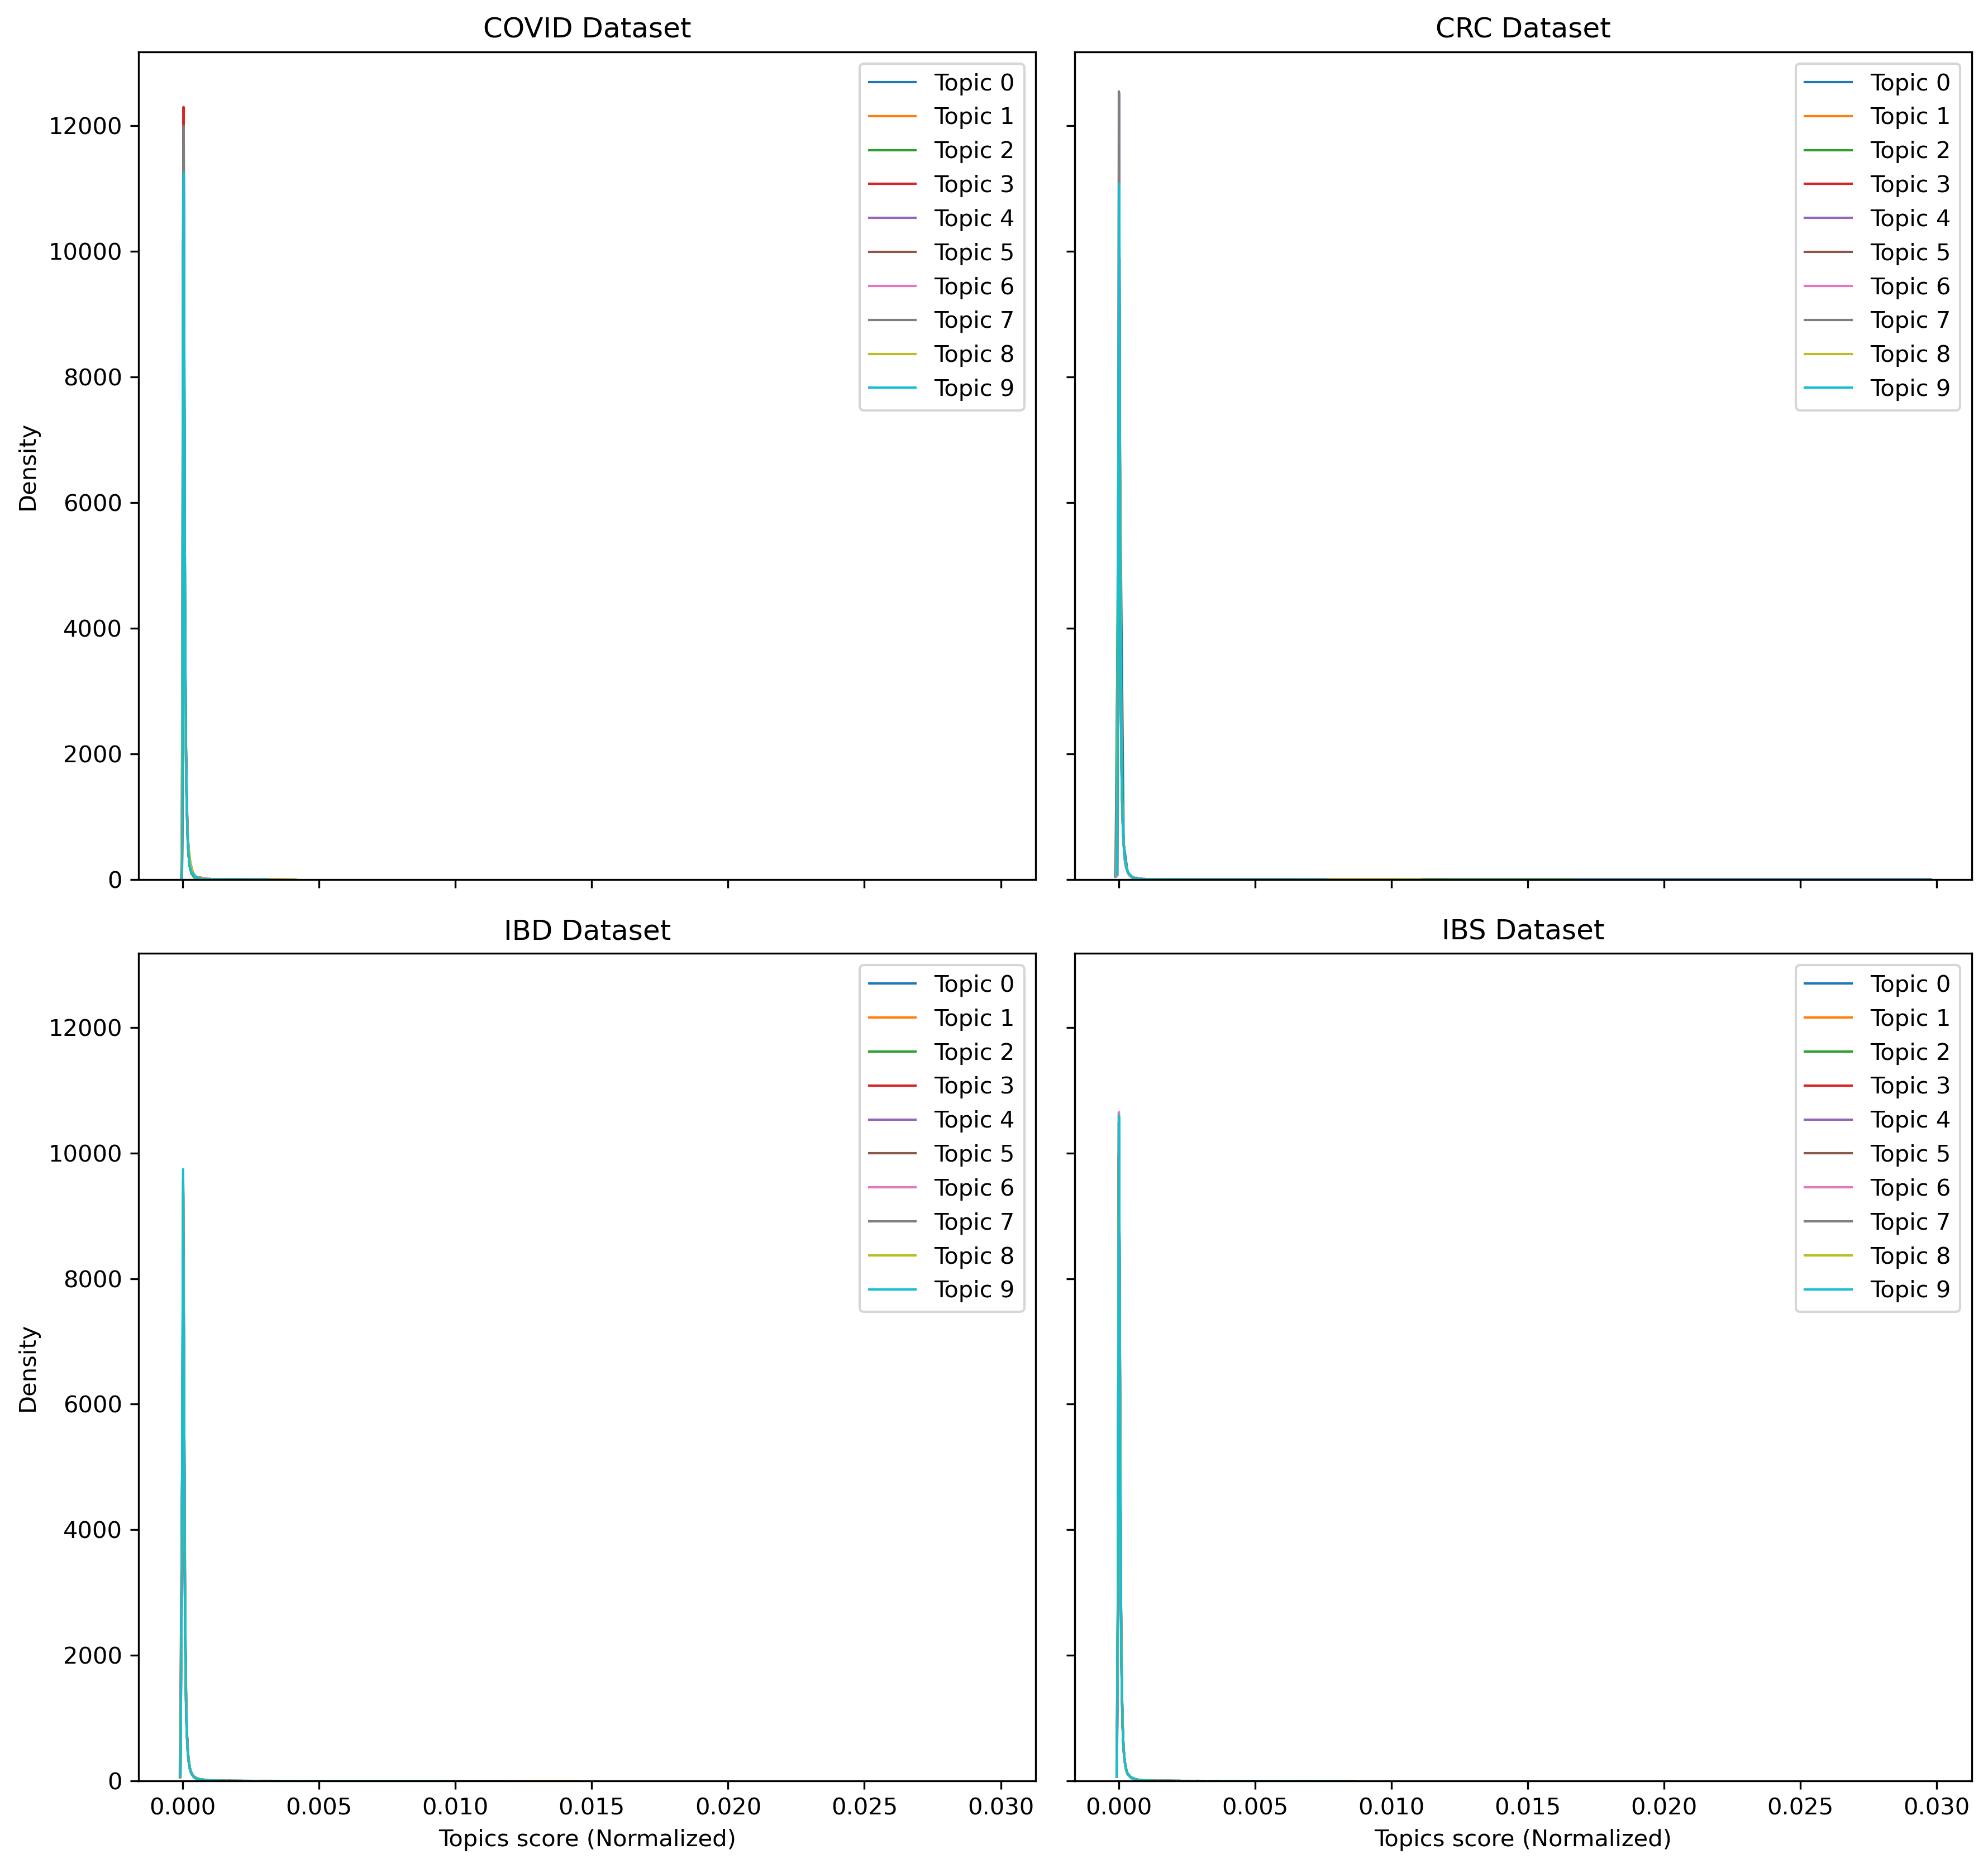

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True, dpi=300)
axes = axes.flatten()
data_list = ['covid','crc','ibd','ibs']
# Plot KDE for each dataset (row-wise)
for i, dataset in enumerate(data_list):
    ax = axes[i]
    df = topic_gene_dist_dict[dataset]
    for idx, row in df.iterrows():
        sns.kdeplot(row.values, ax=ax, linewidth=1,label=f"Topic {idx}")  # label only first 2 for clarity

    ax.set_title(f"{dataset.upper()} Dataset")
    ax.set_xlabel("Topics score (Normalized)")
    ax.set_ylabel("Density")
    ax.legend()
    ax.grid(False)

# Add a main title
plt.suptitle("", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("Topic_Score_distribution.svg")

In [37]:
## get packages
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from scipy.special import rel_entr
import matplotlib.pyplot as plt
import networkx as nx

In [38]:
# --- Jensen-Shannon Distance function ---
def jensen_shannon(p, q):
    p = np.array(p)
    q = np.array(q)
    m = 0.5 * (p + q)
    jsd = 0.5 * np.sum(rel_entr(p, m)) + 0.5 * np.sum(rel_entr(q, m))
    return np.sqrt(jsd)  # return actual JSD (square root of JS divergence)

In [54]:
# --- Input dataframes (already normalized topic matrices) ---
def best_matching_topics(dataname1, dataname2, ax):
    # --- Add small epsilon to avoid log(0) in JSD ---
    df_gene_phi_normalized_1 = topic_gene_dist_dict[dataname1]
    df_gene_phi_normalized_2 = topic_gene_dist_dict[dataname2]
    
    epsilon = 1e-12
    df_gene_phi_normalized_1 = df_gene_phi_normalized_1 + epsilon
    df_gene_phi_normalized_2 = df_gene_phi_normalized_2 + epsilon

    # --- Compute JSD matrix ---
    num_gene_phi_normalized_1 = df_gene_phi_normalized_1.shape[0]
    num_gene_phi_normalized_2 = df_gene_phi_normalized_2.shape[0]
    jsd_matrix = np.zeros((num_gene_phi_normalized_1, num_gene_phi_normalized_2))

    for i in range(num_gene_phi_normalized_1):
        for j in range(num_gene_phi_normalized_2):
            jsd_matrix[i, j] = jensen_shannon(df_gene_phi_normalized_1.iloc[i].values, df_gene_phi_normalized_2.iloc[j].values)

    # --- Optimal Matching: Hungarian algorithm (minimize JSD) ---
    row_ind, col_ind = linear_sum_assignment(jsd_matrix)

    # --- Build matching dataframe with JSD ---
    match_df = pd.DataFrame({
        f'{dataname1}_Topic': col_ind,
        f'{dataname2}_Topic': row_ind,
        'Jensen_Shannon_Distance': jsd_matrix[row_ind, col_ind],
        'Similarity': 1 - jsd_matrix[row_ind, col_ind]
    }).sort_values(by=f'{dataname1}_Topic').reset_index(drop=True)

    # --- Plot Bipartite Network ---
    G = nx.Graph()

    data1_nodes = [f"{dataname1}_{i}" for i in range(num_gene_phi_normalized_1)]
    data2_nodes = [f"{dataname2}_{i}" for i in range(num_gene_phi_normalized_2)]
    G.add_nodes_from(data1_nodes, bipartite=0)
    G.add_nodes_from(data2_nodes, bipartite=1)

    for data1_idx, data2_idx in zip(col_ind, row_ind):
        data1_node = f"{dataname1}_{data1_idx}"
        data2_node = f"{dataname2}_{data2_idx}"
        jsd = jsd_matrix[data1_idx, data2_idx]
        similarity = 1 - jsd
        G.add_edge(data1_node, data2_node, weight=similarity)

    # Bipartite layout
    pos = dict()
    pos.update((node, (0, i)) for i, node in enumerate(data1_nodes))
    pos.update((node, (1, i)) for i, node in enumerate(data2_nodes))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=data1_nodes, node_color='skyblue', node_size=800, label=dataname1, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=data2_nodes, node_color='lightgreen', node_size=800, label=dataname2, ax=ax)

    # Draw edges
    edges = G.edges(data=True)
    edge_labels = {(u, v): f"{d['weight']:.4f}" for u, v, d in edges}
    edge_weights = [3 * (1 - d['weight']) for (_, _, d) in edges]  # thicker = more similar

    nx.draw_networkx_edges(G, pos, edgelist=edges, width=edge_weights, alpha=0.6, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, ax=ax)
    ax.set_title(f"Best Matching Topics between {dataname1}-{dataname2}", fontsize=14)

In [55]:
import itertools

conditions = ['covid', 'crc', 'ibd', 'ibs']
pairs = list(itertools.combinations(conditions, 2))

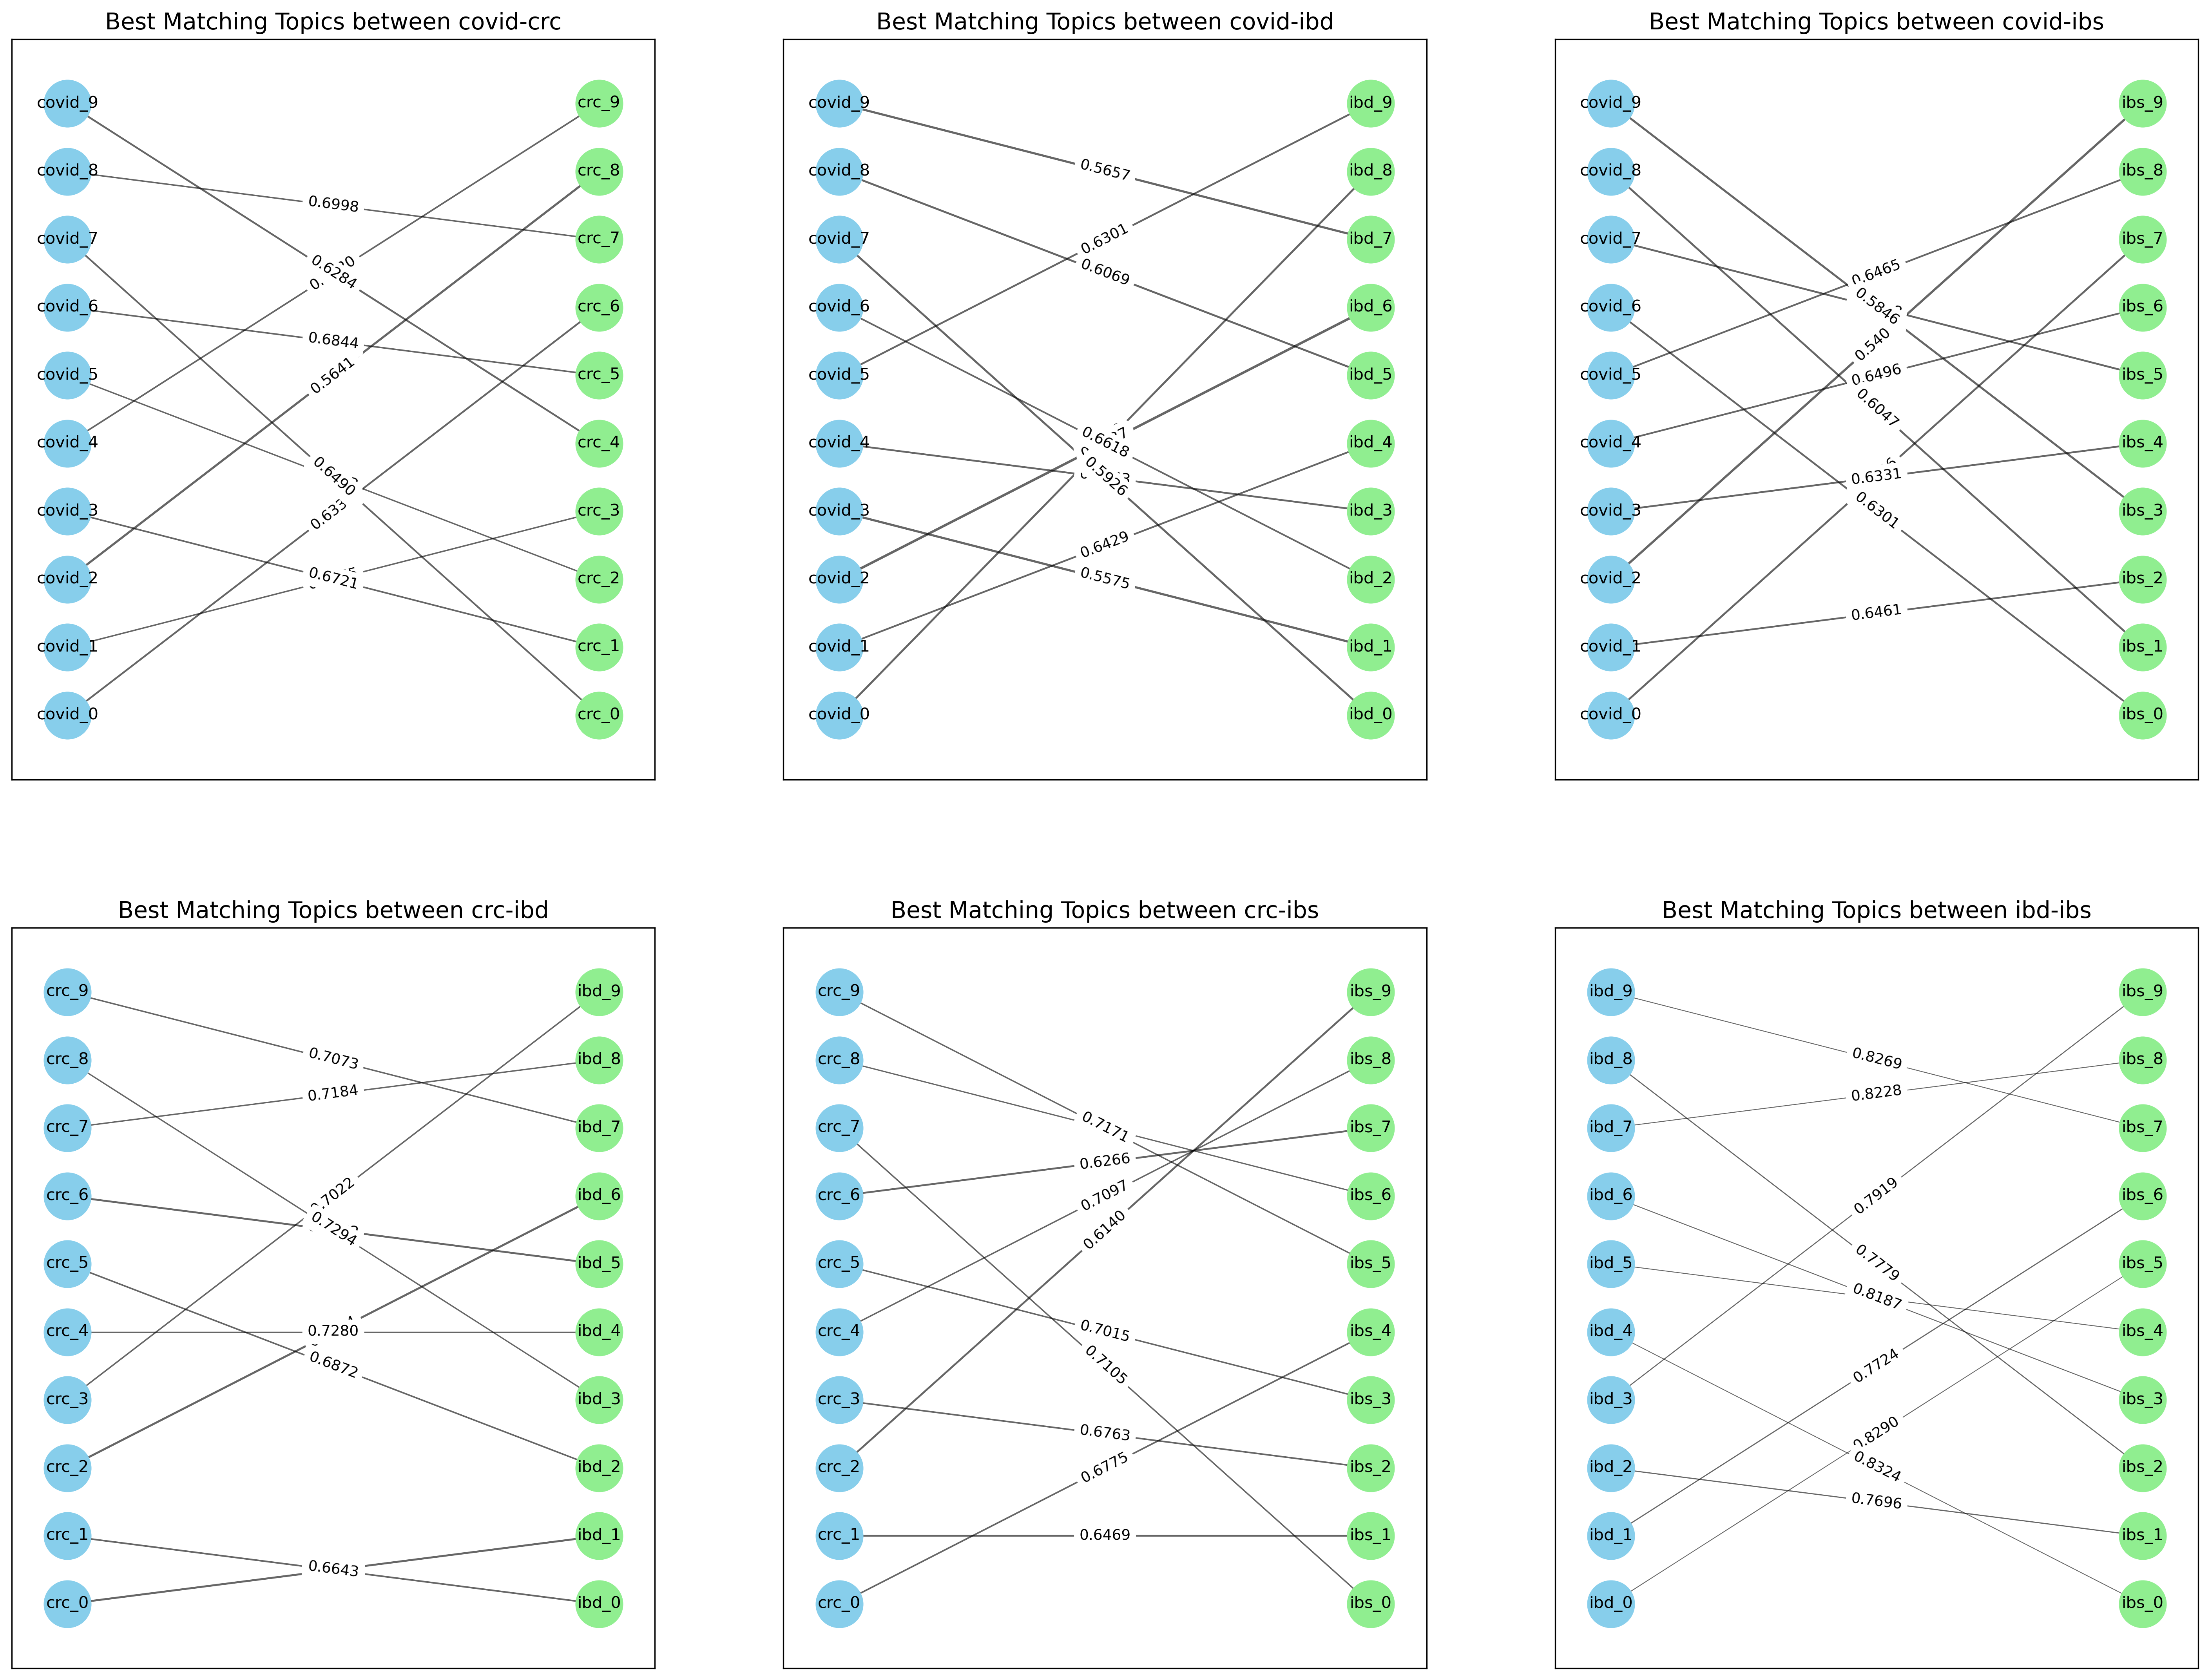

In [57]:
fig, axes = plt.subplots(2,3, figsize=(24,18), dpi=300)
axes_f = axes.flatten()
for i in range(len(pairs)):
    dataname1, dataname2 = pairs[i]
    best_matching_topics(dataname1, dataname2, ax=axes_f[i])

In [ ]:
#######################################

In [ ]:
#list topic weights

In [39]:
curr_model = load_model(ckpts_covid_t10_a5e2[-1], covid_docSet)
embeds_df = get_embeds(curr_model, covid_docSet) 
embeds_df.columns = [f"topic_{i}" for i in embeds_df.columns]
df_topic = pd.concat([covid_docSet.samp_metadata.reset_index(),embeds_df.reset_index()], axis=1).drop('index', axis=1)

In [41]:
data_list = ['covid','crc','ibd','ibs']
for i in range(4):
    data_name = data_list[i]
    models_name_list = globals()[f"ckpts_{data_name}_t10_a5e2"]
    dataset = globals()[f"{data_name}_docSet"]
    model_name = models_name_list[-1]
    curr_model = load_model(model_name, dataset)
    embeds_df = get_embeds(curr_model, dataset)
    embeds_df.columns = [f"topic_{i}" for i in embeds_df.columns]
    df_topic = pd.concat([dataset.samp_metadata.reset_index(),embeds_df.reset_index()], axis=1).drop('index', axis=1)
    df_topic.to_csv(f"{data_name}.topics.csv",header=True, index=False)